In [2]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

from datetime import datetime

In [7]:
fecha = datetime(2027, 7, 24, 16, 30, 12)

fecha

datetime.datetime(2027, 7, 24, 16, 30, 12)

In [8]:
str(fecha)

'2027-07-24 16:30:12'

In [15]:
fecha.strftime("%Y-%m-%d-%I-%M-%S %F %T") # I - Horas meridiano

'2027-07-24-04-30-12 2027-07-24 16:30:12'

In [17]:
datetime.strptime("2025/07/24 18:05:35", "%Y/%m/%d %H:%M:%S")

datetime.datetime(2025, 7, 24, 18, 5, 35)

## Análisis

In [20]:
iau = pandas.read_csv("IAU.csv")
iau.head()

,ID,H,G,Epoch,MeanAnomaly,ArgPerihelion,LongAscNode,Inclination,Eccentricity,MeanMotion,...,NObs,NOppositions,ObsStart,ObsEnd,RMS,CoarsePerturbers,PrecisePerturbers,Computer,ReadableDesignation,LastObsDate
0,00001,3.35,0.15,K2555,188.70270,73.27343,80.25220,10.58780,0.079401,0.214247,...,7291.0,125,1801,024,0.70,M-v,30k,MPCLINUX,(1) Ceres,20241101
1,00101,8.39,0.15,K2555,276.16155,347.78345,343.36446,10.19186,0.140582,0.237343,...,7049.0,64,1871,025,0.50,M-v,3Ek,MPCLINUX,(101) Helena,20250722
2,00201,8.57,0.15,K2555,78.29807,181.33806,156.86887,5.75565,0.179436,0.224608,...,11713.0,67,1879,025,0.49,M-v,3Ek,MPCLINUX,(201) Penelope,20250320
3,00301,10.53,0.15,K2555,99.07971,123.55725,142.28592,4.89846,0.065735,0.219187,...,8190.0,61,1890,025,0.56,M-v,3Ek,MPCLINUX,(301) Bavaria,20250719
4,00401,9.45,0.15,K2555,320.78135,301.82253,36.03131,5.96149,0.030725,0.160960,...,11484.0,60,1895,025,0.48,M-v,3Ek,MPCLINUX,(401) Ottilia,20250723


In [24]:
iau["LastObsDate"].iloc[0]

np.int64(20241101)

In [25]:
datetime.strptime(iau["LastObsDate"].iloc[0].astype(str), "%Y%m%d")

datetime.datetime(2024, 11, 1, 0, 0)

In [27]:
iau["LastObsDate"].apply(lambda fecha: datetime.strptime(str(fecha), "%Y%m%d"))

0       2024-11-01
1       2025-07-22
2       2025-03-20
3       2025-07-19
4       2025-07-23
           ...    
14431   2025-05-04
14432   2025-05-04
14433   2025-07-20
14434   2025-07-04
14435   2025-07-18
Name: LastObsDate, Length: 14436, dtype: datetime64[ns]

In [28]:
pandas.to_datetime(iau["LastObsDate"], format="%Y%m%d", errors="coerce")

0       2024-11-01
1       2025-07-22
2       2025-03-20
3       2025-07-19
4       2025-07-23
           ...    
14431   2025-05-04
14432   2025-05-04
14433   2025-07-20
14434   2025-07-04
14435   2025-07-18
Name: LastObsDate, Length: 14436, dtype: datetime64[ns]

In [30]:
iau["LastObsDateFix"] = pandas.to_datetime(iau["LastObsDate"], format="%Y%m%d", errors="coerce")
iau.head()

,ID,H,G,Epoch,MeanAnomaly,ArgPerihelion,LongAscNode,Inclination,Eccentricity,MeanMotion,...,NOppositions,ObsStart,ObsEnd,RMS,CoarsePerturbers,PrecisePerturbers,Computer,ReadableDesignation,LastObsDate,LastObsDateFix
0,00001,3.35,0.15,K2555,188.70270,73.27343,80.25220,10.58780,0.079401,0.214247,...,125,1801,024,0.70,M-v,30k,MPCLINUX,(1) Ceres,20241101,2024-11-01
1,00101,8.39,0.15,K2555,276.16155,347.78345,343.36446,10.19186,0.140582,0.237343,...,64,1871,025,0.50,M-v,3Ek,MPCLINUX,(101) Helena,20250722,2025-07-22
2,00201,8.57,0.15,K2555,78.29807,181.33806,156.86887,5.75565,0.179436,0.224608,...,67,1879,025,0.49,M-v,3Ek,MPCLINUX,(201) Penelope,20250320,2025-03-20
3,00301,10.53,0.15,K2555,99.07971,123.55725,142.28592,4.89846,0.065735,0.219187,...,61,1890,025,0.56,M-v,3Ek,MPCLINUX,(301) Bavaria,20250719,2025-07-19
4,00401,9.45,0.15,K2555,320.78135,301.82253,36.03131,5.96149,0.030725,0.160960,...,60,1895,025,0.48,M-v,3Ek,MPCLINUX,(401) Ottilia,20250723,2025-07-23


In [36]:
reporte1 = iau[["LastObsDateFix", "NObs"]].sort_values("LastObsDateFix").set_index("LastObsDateFix")
reporte1.head()

,NObs
LastObsDateFix,
1998-07-31,21.0
2001-03-31,9.0
2001-10-25,5.0
2001-12-14,30.0
2002-04-06,69.0


In [47]:
reporte1.resample("YE").mean()

,NObs
LastObsDateFix,
1998-12-31,21.000000
1999-12-31,NaN
2000-12-31,NaN
2001-12-31,14.666667
2002-12-31,69.000000
2003-12-31,NaN
2004-12-31,38.333333
2005-12-31,25.500000
2006-12-31,34.000000


<Axes: xlabel='LastObsDateFix'>

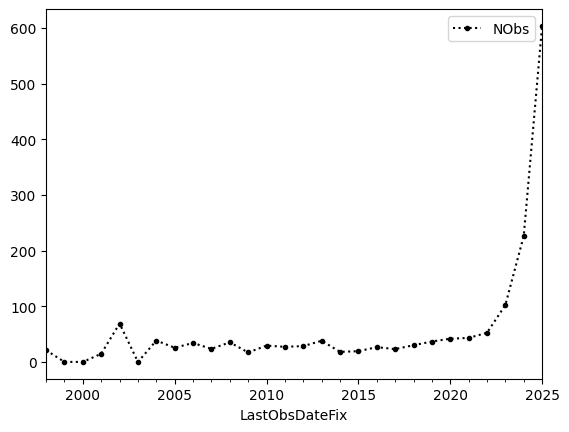

In [46]:
reporte1.resample("YE").mean().fillna(0).plot(marker=".", linestyle=":", color="black")

# Defunciones COVID-19

In [48]:
covid = pandas.read_csv("defunciones_COVID-19.csv")
covid.head()

,edad,sexo,fec_defuncion,causa_registro,alcaldia,lugarmuerte
0,67.0,Hombre,30-01-2020,"CHOQUE SEPTICO, NEUMONIA ATIPICA POR SARS COV ...",TLALPAN,Hospital
1,74.0,Hombre,19-03-2020,"NEUMONIA ATIPICA, PB INFECCION POR COVID 19",IZTACALCO,Hospital
2,61.0,Mujer,23-03-2020,"INSUFICIENCIA RESPIRATORIA AGUDA, NEUMONIA VIR...",BENITO JUAREZ,Hospital
3,60.0,Hombre,26-03-2020,"SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA, ...",ALVARO OBREGON,Hospital
4,62.0,Hombre,27-03-2020,"NEUMONIA GRAVE, COVID 19 CONFIRMADO.",IZTAPALAPA,Hospital


In [ ]:
# covid["fecha"] = pandas.to_datetime(covid["fec_defuncion"], format="%d-%m-%Y", errors="coerce")
covid["fecha"] = pandas.to_datetime(covid["fec_defuncion"], dayfirst=True).dt.strftime("%d-%m-%Y")
covid["fecha"] = pandas.to_datetime(covid["fecha"], dayfirst=True)
covid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64043 entries, 0 to 64042
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   edad            64038 non-null  float64       
 1   sexo            64043 non-null  object        
 2   fec_defuncion   64043 non-null  object        
 3   causa_registro  64043 non-null  object        
 4   alcaldia        63731 non-null  object        
 5   lugarmuerte     64043 non-null  object        
 6   fecha           64043 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 3.4+ MB


In [76]:
reporte2 = covid[["fecha", "edad", "sexo", "alcaldia", "lugarmuerte", "causa_registro"]].sort_values("fecha").set_index("fecha")
reporte2.head()

,edad,sexo,alcaldia,lugarmuerte,causa_registro
fecha,,,,,
2020-01-30,67.0,Hombre,TLALPAN,Hospital,"CHOQUE SEPTICO, NEUMONIA ATIPICA POR SARS COV ..."
2020-03-19,74.0,Hombre,IZTACALCO,Hospital,"NEUMONIA ATIPICA, PB INFECCION POR COVID 19"
2020-03-23,61.0,Mujer,BENITO JUAREZ,Hospital,"INSUFICIENCIA RESPIRATORIA AGUDA, NEUMONIA VIR..."
2020-03-26,60.0,Hombre,ALVARO OBREGON,Hospital,"SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA, ..."
2020-03-27,62.0,Hombre,IZTAPALAPA,Hospital,"NEUMONIA GRAVE, COVID 19 CONFIRMADO."


In [78]:
reporte2.resample("D").size().head()

fecha
2020-01-30    1
2020-01-31    0
2020-02-01    0
2020-02-02    0
2020-02-03    0
Freq: D, dtype: int64

<Axes: xlabel='fecha'>

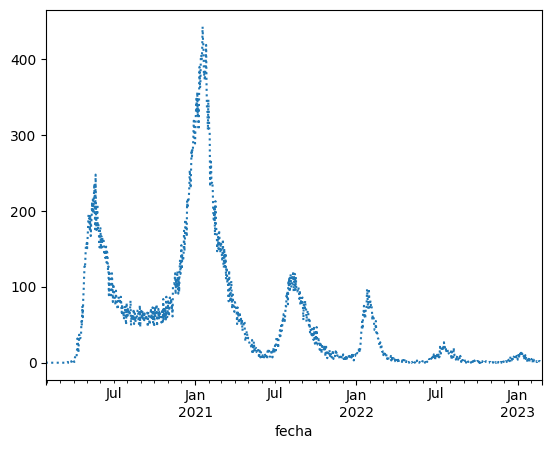

In [89]:
defun = reporte2.resample("D").size()
defun.plot(linestyle=":")

## Análisis de tendencia en series temporales

La **estacionalidad** es un patrón repetitivo y predecible que ocurre en intervalos fijos en el tiempo.

* **Tendencia (T)** - Pratrón a largo plazo
* **Estacionalidad (S)** - 
* **Ciclo (C)**
* **Ruido o Residuo (R)**

> Modelo aditivo

$$
Y_t = T_t + S_t + C_t + R_t
$$

> Modelo multiplicativo

$$
Y_t = T_t * S_t * C_t * R_t
$$

### Medias Móviles

$$
T_t = \frac{1}{k} \sum_{i=t-k+1}^{t} Y_t
$$

In [90]:
MA = defun.rolling(window=7).mean()
MA

fecha
2020-01-30         NaN
2020-01-31         NaN
2020-02-01         NaN
2020-02-02         NaN
2020-02-03         NaN
                ...   
2023-02-21    2.142857
2023-02-22    2.142857
2023-02-23    2.142857
2023-02-24    1.714286
2023-02-25    1.571429
Freq: D, Length: 1123, dtype: float64

<Axes: xlabel='fecha'>

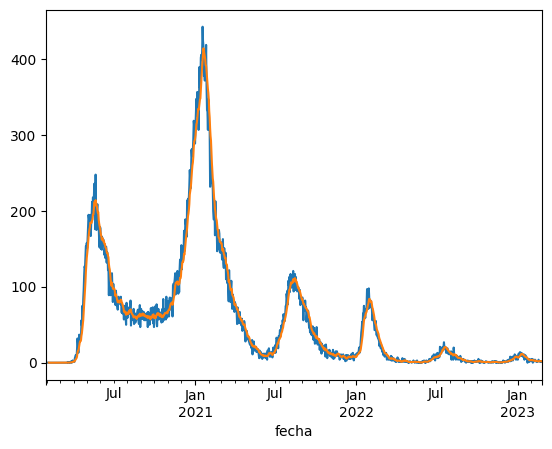

In [91]:
defun.plot()
MA.plot()

## Descomposición STL

* Tendencia (suavizada)
* Estacionalidad (repetitivo)
* Residuo (aleatorio)

* **Pronóstico**: estimar la evolución futura
* **Detección de rupturas**:
* **Análisis de políticas**:

In [92]:
from statsmodels.tsa.seasonal import STL

* `series` - Serie temporal
* `period` - Número de observaciones por ciclo estacional (52)
* `seasonal` - Tamaño de suavizado (7)
* `trend`
* `low_pass`
* `seasonal_deg`
* `trend_deg`
* `seasonal_jump`
* `trend_jump`
* `lowpass_jump`
* `inner_iter`
* `outer_iter`

In [95]:
stl = STL(defun, period=52, robust=True)

result_stl = stl.fit()

reporte3 = pandas.DataFrame({
    "Tendencia": result_stl.trend,
    "Estacionalidad": result_stl.seasonal,
    "Residuo": result_stl.resid,
}, index=defun.index)

reporte3

,Tendencia,Estacionalidad,Residuo
fecha,,,
2020-01-30,-19.485324,19.362391,1.122933
2020-01-31,-18.690284,17.218845,1.471439
2020-02-01,-17.894273,18.025825,-0.131552
2020-02-02,-17.097252,15.759356,1.337897
2020-02-03,-16.299181,15.767229,0.531952
...,...,...,...
2023-02-21,3.105290,-1.031536,-1.073754
2023-02-22,3.022691,-1.390474,0.367783
2023-02-23,2.939437,0.343119,-1.282556


<Axes: xlabel='fecha'>

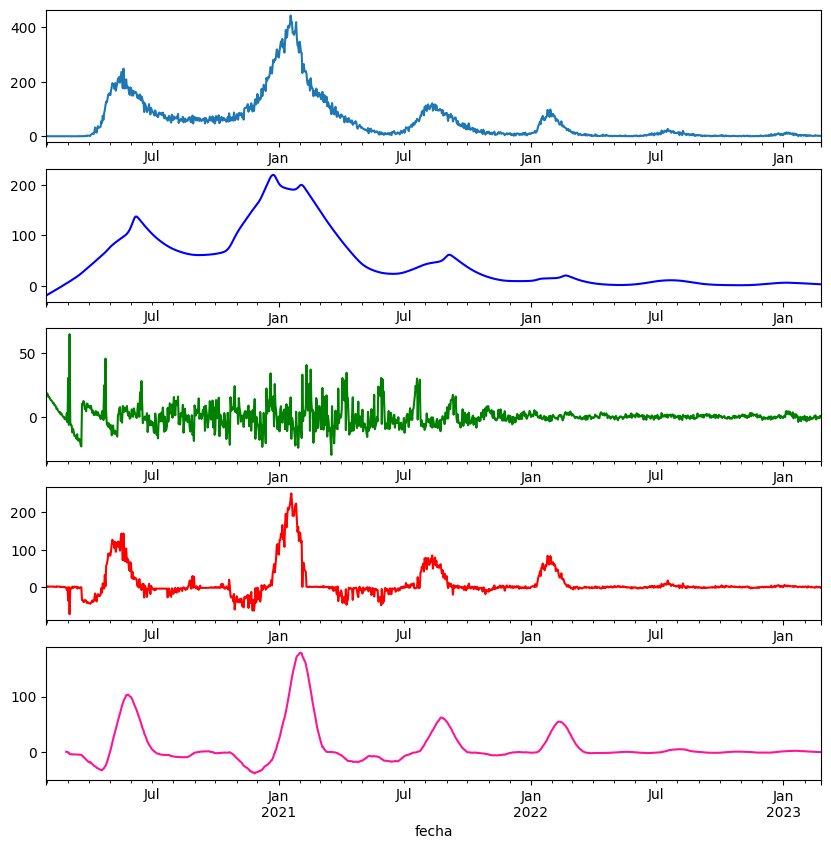

In [111]:
figure, axis = pyplot.subplots(5, figsize=(10, 10))

defun.plot(ax=axis[0])
reporte3["Tendencia"].plot(ax=axis[1], color="blue")
reporte3["Estacionalidad"].plot(ax=axis[2], color="green")
reporte3["Residuo"].plot(ax=axis[3], color="red")
reporte3["Residuo"].rolling(window=30).mean().plot(ax=axis[4], color="deeppink")

# Acciones de Aeroméxico



In [125]:
tesla = pandas.read_csv("TSLA.csv", parse_dates=True)

tesla.head()

,Date,Open,High,Low,Close,Adj Close
0,2019-09-30,16.200001,16.265333,15.740667,16.058001,16.058001
1,2019-10-01,16.100000,16.396667,15.942000,16.312668,16.312668
2,2019-10-02,16.219334,16.309999,15.962000,16.208668,16.208668
3,2019-10-03,15.457333,15.632000,14.952000,15.535333,15.535333
4,2019-10-04,15.440667,15.652000,15.204667,15.428667,15.428667


In [126]:
serie = tesla[["Date", "Close"]].sort_values("Date").set_index("Date")
serie.head()

,Close
Date,
2019-09-30,16.058001
2019-10-01,16.312668
2019-10-02,16.208668
2019-10-03,15.535333
2019-10-04,15.428667


<Axes: xlabel='Date'>

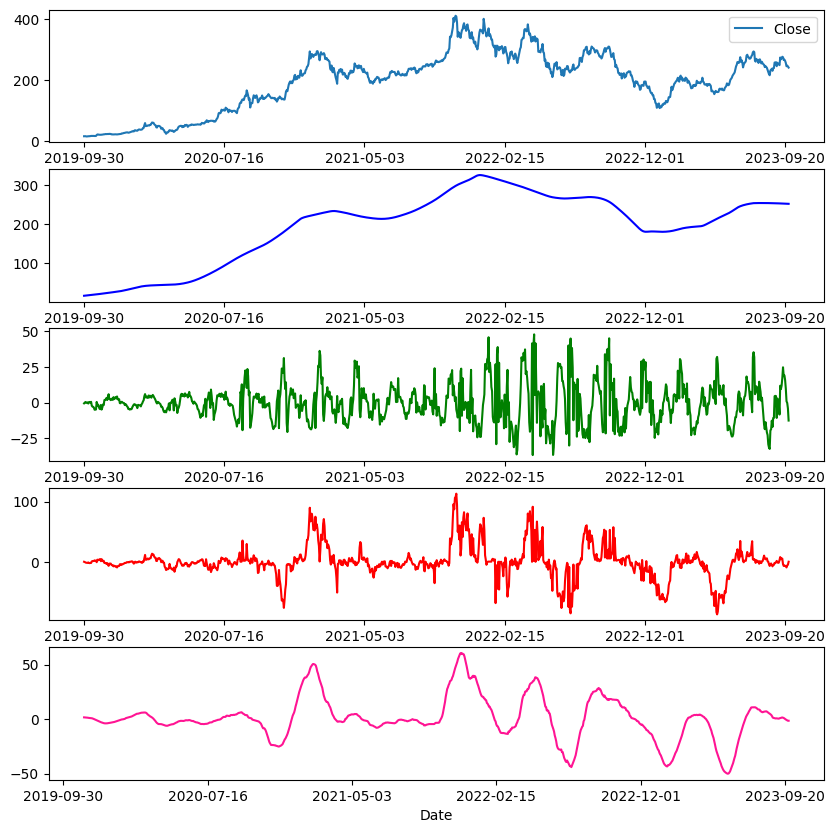

In [127]:
stl = STL(serie, period=52, robust=True)

result_stl = stl.fit()

reporte4 = pandas.DataFrame({
    "Tendencia": result_stl.trend,
    "Estacionalidad": result_stl.seasonal,
    "Residuo": result_stl.resid,
}, index=serie.index)

reporte4

figure, axis = pyplot.subplots(5, figsize=(10, 10))

serie.plot(ax=axis[0])
reporte4["Tendencia"].plot(ax=axis[1], color="blue")
reporte4["Estacionalidad"].plot(ax=axis[2], color="green")
reporte4["Residuo"].plot(ax=axis[3], color="red")
reporte4["Residuo"].rolling(window=30).mean().plot(ax=axis[4], color="deeppink")

# Indexación de fechas

In [130]:
pandas.date_range("2025-01-01", "2025-03-01", freq="D")

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12',
               '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-16',
               '2025-01-17', '2025-01-18', '2025-01-19', '2025-01-20',
               '2025-01-21', '2025-01-22', '2025-01-23', '2025-01-24',
               '2025-01-25', '2025-01-26', '2025-01-27', '2025-01-28',
               '2025-01-29', '2025-01-30', '2025-01-31', '2025-02-01',
               '2025-02-02', '2025-02-03', '2025-02-04', '2025-02-05',
               '2025-02-06', '2025-02-07', '2025-02-08', '2025-02-09',
               '2025-02-10', '2025-02-11', '2025-02-12', '2025-02-13',
               '2025-02-14', '2025-02-15', '2025-02-16', '2025-02-17',
               '2025-02-18', '2025-02-19', '2025-02-20', '2025-02-21',
               '2025-02-22', '2025-02-23', '2025-02-24', '2025-02-25',
      

In [135]:
pandas.date_range(start="2025-01-01", periods=20, freq="MS")

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01'],
              dtype='datetime64[ns]', freq='MS')